## XGBoost: A Comprehensive Guide

XGBoost (eXtreme Gradient Boosting) is a powerful and widely used machine learning algorithm. This notebook will cover everything from the basics of what XGBoost is to advanced concepts and practical implementation.

-----


### 1\. Introduction to XGBoost 🚀

XGBoost is an optimized distributed gradient boosting library designed to be **highly efficient, flexible, and portable**. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way. It's often the algorithm of choice for tabular datasets in competitive machine learning.

**Key Features of XGBoost:**

  * **Speed and Performance:** Highly optimized C++ backend, parallel processing, and efficient handling of sparse data.
  * **Scalability:** Can run on a single machine or in distributed environments (e.g., Hadoop, Spark).
  * **Regularization:** Includes L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting.
  * **Handling Missing Values:** Can automatically learn the best direction for missing values.
  * **Flexibility:** Supports various objective functions and evaluation metrics.
  * **Built-in Cross-Validation:** Allows direct integration of cross-validation during training.


### 2\. Gradient Boosting Refresher (The "GB" in XGBoost) 📈

XGBoost builds upon the principles of **Gradient Boosting**. As discussed previously, Gradient Boosting iteratively builds an ensemble of weak learners (typically decision trees) by trying to correct the errors of the previous learners.

**Recall the core idea:**

1.  Start with an initial prediction (e.g., average target value).
2.  In each step, calculate the **residuals** (the difference between actual values and current predictions) or, more formally, the **negative gradient of the loss function**.
3.  Train a new weak learner (a decision tree) to predict these residuals/gradients.
4.  Add the prediction of this new weak learner (scaled by a `learning_rate`) to the ensemble's current prediction.
5.  Repeat until a stopping criterion is met.

XGBoost takes this core idea and adds a ton of sophisticated optimizations and enhancements.


### 3\. Why "eXtreme" Gradient Boosting? (Key Enhancements) 🔥

XGBoost goes "eXtreme" with several key enhancements over traditional Gradient Boosting:

1.  **Regularization (L1 and L2):**

      * XGBoost includes regularization terms in its objective function (loss function). This penalizes complex models, preventing overfitting.
      * This is a crucial differentiator from basic Gradient Boosting implementations, making XGBoost more robust.

2.  **Second-Order Approximation:**

      * Traditional Gradient Boosting uses only the first derivative (gradient) of the loss function.
      * XGBoost uses a **second-order Taylor expansion** of the loss function. This means it uses both the first and second derivatives (Hessian). This provides a more precise estimation of the optimal step to take in the gradient descent, leading to faster convergence and better accuracy.

3.  **Handling Missing Values:**

      * XGBoost has a built-in ability to handle missing values (`np.nan` or `None`). When splitting a node, it can automatically learn the best direction (left or right branch) to send samples with missing values.

4.  **Smarter Tree Pruning (Direct Pruning):**

      * Instead of `pre-pruning` (stopping tree growth early), XGBoost uses `post-pruning` or "direct pruning". It grows the tree to its `max_depth` and then prunes backward, removing branches that don't add enough gain to the objective function. This often leads to better trees.

5.  **Block Structure for Parallelism:**

      * XGBoost stores data in an in-memory `Block` structure. This allows features to be accessed column-wise, enabling parallel computation of gain for splits across features. This significantly speeds up training.

6.  **Out-of-Core Computing:**

      * Can handle datasets that don't fit into memory by processing data in chunks.

7.  **Cache-aware Access:**

      * Optimizes data access to reduce cache misses, further boosting performance.

8.  **Weighted Quantile Sketch for Splits:**

      * Efficiently finds optimal split points for continuous features, especially with weighted data.

### 4\. Mathematical Foundation (Simplified) 🧮

Here are all the **core mathematical formulas** required for understanding how **XGBoost** works, especially for **regression** and **binary classification**:

---

#### 🔢 1. **Loss Function**

XGBoost uses a **second-order Taylor approximation** of the loss function around the current prediction.

For a sample $i$:

* Let $y_i$ be the true value
* Let $\hat{y}_i^{(t-1)}$ be the prediction at iteration $t-1$

We define:

* **Gradient**:

  $$
  g_i = \frac{\partial L(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}}
  $$

* **Hessian**:

  $$
  h_i = \frac{\partial^2 L(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2}
  $$

---

#### 🌳 2. **XGBoost Tree Objective at Tree t**

The objective at tree $t$ is:

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)
$$

Where:

* $f_t(x_i)$ is the score/output of the tree on sample $x_i$
* $\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$ is the regularization term

  * $T$: number of leaves
  * $w_j$: score on leaf $j$
  * $\gamma$: complexity penalty per leaf
  * $\lambda$: L2 regularization on leaf weights

---

#### 📘 3. **Leaf Score Formula (Similarity Score)**

For a leaf $j$ containing a set of samples $I_j$, the optimal weight $w_j$ is:

$$
w_j = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}
$$

---

#### 🔍 4. **Leaf Similarity Score (Gain at Leaf)**

$$
\text{Score}(I_j) = -\frac{1}{2} \cdot \frac{\left(\sum_{i \in I_j} g_i \right)^2}{\sum_{i \in I_j} h_i + \lambda}
$$

---

#### ✂️ 5. **Split Gain Formula (Information Gain)**

When you split a node into **left child (L)** and **right child (R)**:

$$
\text{Gain} = \frac{1}{2} \left(
\frac{(\sum_{i \in L} g_i)^2}{\sum_{i \in L} h_i + \lambda} +
\frac{(\sum_{i \in R} g_i)^2}{\sum_{i \in R} h_i + \lambda} -
\frac{(\sum_{i \in L \cup R} g_i)^2}{\sum_{i \in L \cup R} h_i + \lambda}
\right) - \gamma
$$

* Gain must be **positive** to justify a split.

---

#### 🔁 6. **Final Prediction Formula**

The final prediction after $T$ trees is:

$$
\hat{y}_i = \hat{y}_i^{(0)} + \eta \sum_{t=1}^{T} f_t(x_i)
$$

Where:

* $\eta$: learning rate (0 < η ≤ 1)
* $f_t(x_i)$: prediction from tree $t$ for sample $i$
* $\hat{y}_i^{(0)}$: initial prediction (usually mean in regression, log-odds in classification)

---

#### 🎯 Summary Table

| Formula Type                                               | Formula                                                      |
| ---------------------------------------------------------- | ------------------------------------------------------------ |
| Gradient (gᵢ)    | $g_i = \partial L / \partial \hat{y}_i$                      |
| Hessian (hᵢ)     | $h_i = \partial^2 L / \partial \hat{y}_i^2$                  |
| Leaf Weight (wⱼ) | $w_j = -\sum g_i / (\sum h_i + \lambda)$                     |
| Leaf Score       | $-\frac{1}{2} \cdot \frac{(\sum g_i)^2}{\sum h_i + \lambda}$ |
| Gain from Split  | As shown above                                               |
| Final Prediction | $\hat{y} = \hat{y}^{(0)} + \eta \sum f_t(x)$                 |

---



### 5\. Key Hyperparameters in XGBoost ⚙️

Tuning hyperparameters is crucial for optimal performance. Here are some of the most important ones:

#### General Parameters:

  * **`booster`**: `gbtree` (tree-based model, default), `gblinear` (linear model), `dart` (dropout-based).
  * **`n_jobs`**: Number of parallel threads to run. Set to -1 to use all available cores.

#### Booster Parameters (for `gbtree`):

1.  **`n_estimators` (or `num_round` / `num_boost_round`):**

      * **What:** Number of boosting rounds (number of trees to build).
      * **Impact:** Higher values can lead to more accurate models but increase training time and risk of overfitting.
      * **Tuning:** Often tuned in conjunction with `learning_rate`.

2.  **`learning_rate` (or `eta`):**

      * **What:** Step size shrinkage to prevent overfitting. It shrinks the feature weights after each boosting step.
      * **Impact:** Smaller values require more `n_estimators` but make the model more robust to overfitting. Larger values can lead to faster training but might overshoot the optimal solution.
      * **Tuning:** Typically between 0.01 and 0.3.

3.  **`max_depth`:**

      * **What:** Maximum depth of a tree.
      * **Impact:** Controls individual tree complexity. Deeper trees can model more complex relationships but increase overfitting risk. Shallow trees (e.g., 3-10) are common.
      * **Tuning:** Start with a reasonable value and tune.

4.  **`subsample`:**

      * **What:** Fraction of samples used for training each tree.
      * **Impact:** If less than 1.0, it introduces randomness, reducing variance (overfitting). Similar to bagging.
      * **Tuning:** Common values like 0.6 to 0.9.

5.  **`colsample_bytree` / `colsample_bylevel` / `colsample_bynode`:**

      * **What:** Fraction of features (columns) sampled for each tree, at each level, or at each node respectively.
      * **Impact:** Reduces variance and speeds up training.
      * **Tuning:** Common values like 0.6 to 0.9.

6.  **`gamma` (or `min_split_loss`):**

      * **What:** Minimum loss reduction required to make a further partition on a leaf node.
      * **Impact:** A larger `gamma` leads to more conservative (less complex) trees and reduces overfitting.
      * **Tuning:** Can be 0 or small positive values.

7.  **`lambda` (L2 regularization) / `alpha` (L1 regularization):**

      * **What:** Regularization terms applied to weights.
      * **Impact:** Penalize large weights, preventing overfitting. `lambda` (L2) is more common.
      * **Tuning:** Start with defaults and adjust if overfitting is observed.

8.  **`min_child_weight`:**

      * **What:** Minimum sum of instance weight (Hessian) needed in a child. If a split results in a leaf node with a sum of instance weight less than `min_child_weight`, the tree-building process will stop further partitioning.
      * **Impact:** Prevents learning overly specific relationships from very few samples; controls overfitting.
      * **Tuning:** Higher values lead to more conservative models.

#### Learning Task Parameters:

  * **`objective`**: 
            Defines the loss function to be optimized (e.g., `'binary:logistic'` for binary classification, `'multi:softmax'` for multi-class, `'reg:squarederror'` for regression).
  * **`eval_metric`**: 
            Metric used for validation data (e.g., `'logloss'`, `'auc'`, `'rmse'`, `'mae'`).

### 6\. Python Implementation with `XGBoost` Library 🐍

Let's walk through typical usage for classification and regression.

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Sample Data ---
# For Classification (e.g., Titanic dataset or similar structured data)
# Let's create a synthetic classification dataset for simplicity
from sklearn.datasets import make_classification
X_clf, y_clf = make_classification(n_samples=1000, n_features=20, n_informative=10,
                                   n_redundant=5, n_classes=2, random_state=42)

# For Regression
from sklearn.datasets import make_regression
X_reg, y_reg = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

print("Classification Data Shape (X, y):", X_clf.shape, y_clf.shape)
print("Regression Data Shape (X, y):", X_reg.shape, y_reg.shape)
print("-" * 30)

Classification Data Shape (X, y): (1000, 20) (1000,)
Regression Data Shape (X, y): (1000, 10) (1000,)
------------------------------


In [ ]:
# --- 2. Data Splitting ---
# Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

# Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

print("Classification Train/Test Shapes:", X_train_clf.shape, X_test_clf.shape)
print("Regression Train/Test Shapes:", X_train_reg.shape, X_test_reg.shape)
print("-" * 30)

Classification Train/Test Shapes: (700, 20) (300, 20)
Regression Train/Test Shapes: (700, 10) (300, 10)
------------------------------


In [ ]:
# --- 3. XGBoost for Classification ---

print("--- XGBoost Classification Example ---")

# Define the XGBoost Classifier model
# Using common default-ish parameters
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification, outputs probabilities
    eval_metric='logloss',       # Evaluation metric during training
    n_estimators=100,            # Number of boosting rounds (trees)
    learning_rate=0.1,           # Step size shrinkage
    max_depth=5,                 # Max depth of each tree
    subsample=0.8,               # Subsample ratio of the training instance
    colsample_bytree=0.8,        # Subsample ratio of columns when constructing each tree
    use_label_encoder=False,     # Suppress warning for future versions
    random_state=42,             # For reproducibility
    n_jobs=-1                    # Use all available CPU cores
)

# Train the model
xgb_clf.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_clf_proba = xgb_clf.predict_proba(X_test_clf)[:, 1] # Probabilities for AUC
y_pred_clf_class = xgb_clf.predict(X_test_clf)             # Predicted classes

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred_clf_class)
auc_score = roc_auc_score(y_test_clf, y_pred_clf_proba)

print(f"XGBoost Classifier Accuracy: {accuracy:.4f}")
print(f"XGBoost Classifier AUC: {auc_score:.4f}")
print("-" * 30)

--- XGBoost Classification Example ---


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:01:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Accuracy: 0.9167
XGBoost Classifier AUC: 0.9785
------------------------------


In [ ]:
# --- 4. XGBoost for Regression ---

print("--- XGBoost Regression Example ---")

# Define the XGBoost Regressor model
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror', # For regression, common objective
    eval_metric='rmse',           # Evaluation metric during training
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_reg.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = xgb_reg.predict(X_test_reg)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"XGBoost Regressor RMSE: {rmse:.4f}")
print("-" * 30)

--- XGBoost Regression Example ---
XGBoost Regressor RMSE: 35.7740
------------------------------


In [ ]:
# --- 5. Cross-Validation with XGBoost (using sklearn's GridSearchCV) ---

print("--- Hyperparameter Tuning with GridSearchCV (Classification) ---")

# Define a smaller parameter grid for demonstration (tuning can take time)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
}

# Create a StratifiedKFold for classification cross-validation
# n_splits=3 for faster demonstration; typically 5 or 10
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc', # Optimize for AUC score
    verbose=1,         # Show progress
    n_jobs=-1          # Use all available cores
)

grid_search_xgb.fit(X_train_clf, y_train_clf)

print(f"\nBest parameters found: {grid_search_xgb.best_params_}")
print(f"Best cross-validation AUC: {grid_search_xgb.best_score_:.4f}")

# Evaluate on the test set with the best estimator
best_xgb_clf = grid_search_xgb.best_estimator_
y_pred_best_clf_proba = best_xgb_clf.predict_proba(X_test_clf)[:, 1]
final_auc = roc_auc_score(y_test_clf, y_pred_best_clf_proba)
print(f"Test AUC with best parameters: {final_auc:.4f}")
print("-" * 30)

--- Hyperparameter Tuning with GridSearchCV (Classification) ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:01:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Best parameters found: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}
Best cross-validation AUC: 0.9673
Test AUC with best parameters: 0.9797
------------------------------


--- Feature Importance Example ---


<Figure size 1000x600 with 0 Axes>

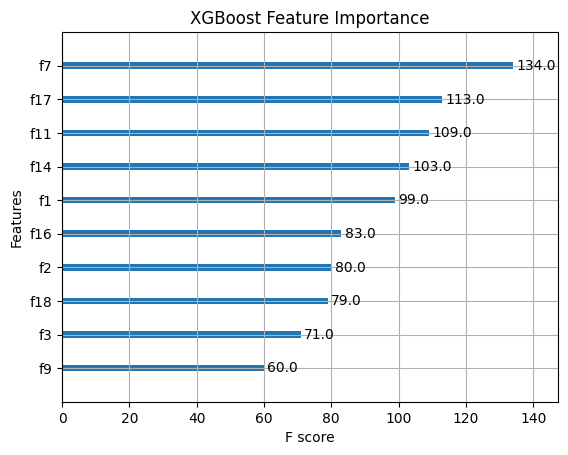

Top 5 Feature Importances:
feature_14: 0.1026
feature_11: 0.0922
feature_15: 0.0737
feature_17: 0.0633
feature_3: 0.0600
------------------------------


In [ ]:
# --- 6. Feature Importance ---

print("--- Feature Importance Example ---")
# Feature importance can be accessed after training
# xgb_clf (from step 3) already trained
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_clf, max_num_features=10) # Plot top 10 features
plt.title('XGBoost Feature Importance')
plt.show()

# You can also get numerical values
importance_scores = xgb_clf.feature_importances_
feature_names = [f'feature_{i}' for i in range(X_clf.shape[1])] # Assuming generic feature names
sorted_indices = np.argsort(importance_scores)[::-1]
print("Top 5 Feature Importances:")
for i in sorted_indices[:5]:
    print(f"{feature_names[i]}: {importance_scores[i]:.4f}")
print("-" * 30)

--- Early Stopping Example ---
[0]	train-logloss:0.63148	valid-logloss:0.64520
[10]	train-logloss:0.30433	valid-logloss:0.38920
[20]	train-logloss:0.18091	valid-logloss:0.29464
[30]	train-logloss:0.11977	valid-logloss:0.24784
[40]	train-logloss:0.08743	valid-logloss:0.22117
[50]	train-logloss:0.06724	valid-logloss:0.20875
[60]	train-logloss:0.05394	valid-logloss:0.20060
[70]	train-logloss:0.04438	valid-logloss:0.19491
[80]	train-logloss:0.03686	valid-logloss:0.19208
[90]	train-logloss:0.03080	valid-logloss:0.19120
[100]	train-logloss:0.02650	valid-logloss:0.19104
[110]	train-logloss:0.02314	valid-logloss:0.18901
[120]	train-logloss:0.02053	valid-logloss:0.18827
[130]	train-logloss:0.01853	valid-logloss:0.18667
[140]	train-logloss:0.01703	valid-logloss:0.18770
[150]	train-logloss:0.01570	valid-logloss:0.18755
[160]	train-logloss:0.01460	valid-logloss:0.18771
[170]	train-logloss:0.01366	valid-logloss:0.18719
[175]	train-logloss:0.01328	valid-logloss:0.18711


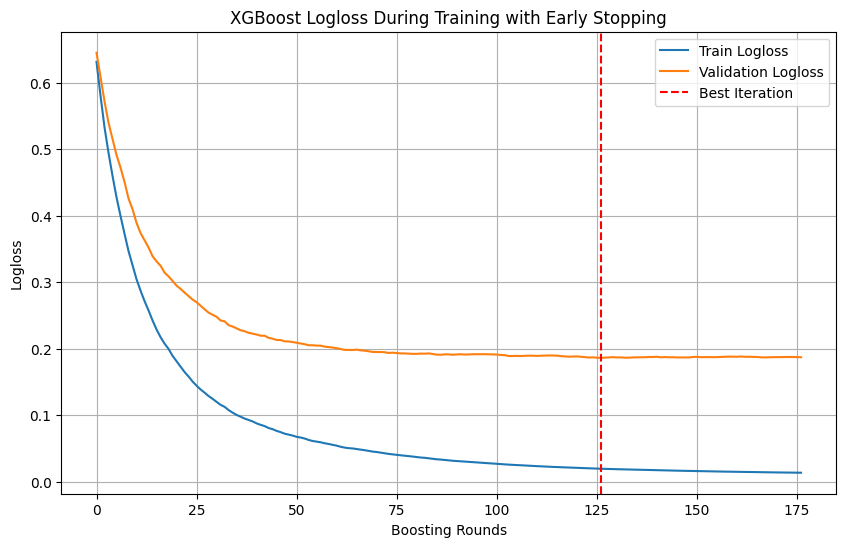

Test AUC with Early Stopping: 0.9781
------------------------------


In [ ]:
# --- 7. Early Stopping (Advanced Training Control) ---

print("--- Early Stopping Example ---")
# Early stopping helps prevent overfitting by stopping training if validation metric
# doesn't improve for a certain number of rounds (`patience`).

# DMatrix is the internal data structure for XGBoost, optimized for performance
dtrain = xgb.DMatrix(X_train_clf, label=y_train_clf)
dtest = xgb.DMatrix(X_test_clf, label=y_test_clf)

# Define parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.1, # learning_rate
    'max_depth': 5,
    'seed': 42,
    'n_jobs': -1
}

# evals_result = {} # To store evaluation results during training - No longer needed

# Train with early stopping
# `num_boost_round`: Max number of boosting rounds
# `early_stopping_rounds`: Stop if validation metric doesn't improve for a certain number of rounds
# `verbose_eval`: Print evaluation results every 'N' rounds
import xgboost as xgb

# Define evaluation results dictionary
evals_result = {}

# Train model
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,  # Max iterations
    evals=[(dtrain, 'train'), (dtest, 'valid')],  # Evaluation sets
    early_stopping_rounds=50,  # Stop if validation metric doesn't improve
    verbose_eval=10,  # Print every 10 rounds
    evals_result=evals_result  # This captures the evaluation history
)

epochs = len(evals_result['train']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, evals_result['train']['logloss'], label='Train Logloss')
plt.plot(x_axis, evals_result['valid']['logloss'], label='Validation Logloss')
plt.axvline(bst.best_iteration, color='red', linestyle='--', label='Best Iteration')
plt.legend()
plt.ylabel('Logloss')
plt.xlabel('Boosting Rounds')
plt.title('XGBoost Logloss During Training with Early Stopping')
plt.grid(True)
plt.show()

# Make predictions with the best model from early stopping
y_pred_es_proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
es_auc = roc_auc_score(y_test_clf, y_pred_es_proba)
print(f"Test AUC with Early Stopping: {es_auc:.4f}")

print("-" * 30)

--- Handling Imbalanced Data (Classification) ---
Calculated scale_pos_weight: 0.99


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:08:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier (Imbalanced handled) AUC: 0.9789
------------------------------
--- `xgboost.cv` for Cross-Validation ---
[0]	train-logloss:0.63288+0.00287	test-logloss:0.64459+0.00512
[10]	train-logloss:0.30902+0.00690	test-logloss:0.38426+0.01973
[20]	train-logloss:0.18468+0.00508	test-logloss:0.28897+0.02074
[30]	train-logloss:0.12576+0.00411	test-logloss:0.24602+0.02381
[40]	train-logloss:0.09321+0.00205	test-logloss:0.22512+0.02809
[50]	train-logloss:0.07206+0.00181	test-logloss:0.21297+0.02943
[60]	train-logloss:0.05739+0.00185	test-logloss:0.20586+0.03220
[70]	train-logloss:0.04650+0.00142	test-logloss:0.19948+0.03340
[80]	train-logloss:0.03826+0.00140	test-logloss:0.19507+0.03429
[90]	train-logloss:0.03228+0.00143	test-logloss:0.19263+0.03454
[100]	train-logloss:0.02756+0.00119	test-logloss:0.19070+0.03334
[110]	train-logloss:0.02409+0.00105	test-logloss:0.18894+0.03333
[120]	train-logloss:0.02132+0.00090	test-logloss:0.18861+0.03408
[130]	train-logloss:0.01900+0.00068	test-

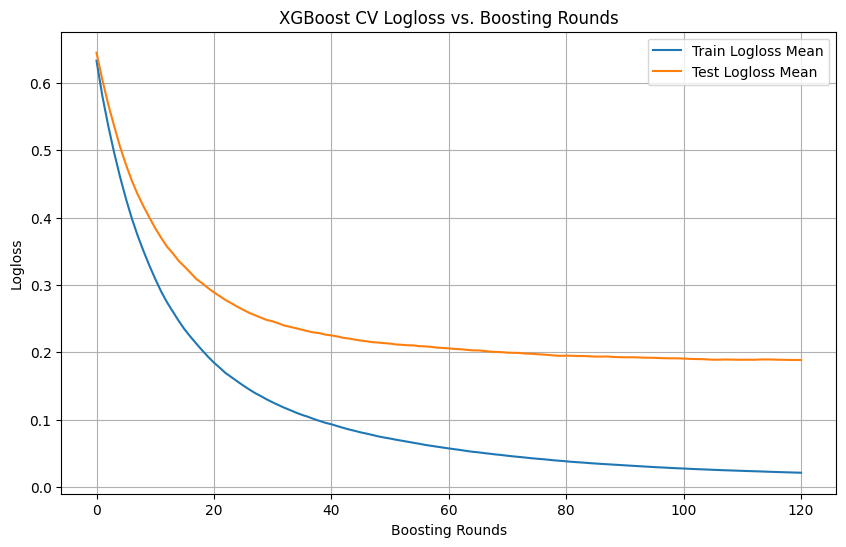

------------------------------


In [ ]:
# --- 8. Handling Imbalanced Data ---

print("--- Handling Imbalanced Data (Classification) ---")
# XGBoost can handle imbalanced datasets using a few strategies:

# 1. `scale_pos_weight`: Controls the balance of positive and negative weights.
#    A common value is `sum(negative_instances) / sum(positive_instances)`.
#    This helps to give more importance to the minority class.
neg_count = np.sum(y_clf == 0)
pos_count = np.sum(y_clf == 1)
scale_pos_weight_val = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_val:.2f}")

xgb_clf_imbalanced = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc', # AUC is often preferred for imbalanced data
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight_val, # Applying the weight
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_clf_imbalanced.fit(X_train_clf, y_train_clf)
y_pred_imbalanced_proba = xgb_clf_imbalanced.predict_proba(X_test_clf)[:, 1]
auc_imbalanced = roc_auc_score(y_test_clf, y_pred_imbalanced_proba)
print(f"XGBoost Classifier (Imbalanced handled) AUC: {auc_imbalanced:.4f}")

# 2. `is_higher_than_previous_auc`
# Instead of `scale_pos_weight`, you can also adjust the `objective` function
# or use appropriate evaluation metrics (like `AUC`, `Precision-Recall Curve`)
# and perform proper sampling techniques (oversampling minority, undersampling majority)
# *outside* XGBoost.

print("-" * 30)

# --- 9. Using `xgboost.cv` for Cross-Validation ---

print("--- `xgboost.cv` for Cross-Validation ---")
# The native `xgboost.cv` function is very efficient for cross-validation
# and can give you an idea of optimal `n_estimators`.

# Convert data to DMatrix format
dtrain_full = xgb.DMatrix(X_clf, label=y_clf)

# Define parameters
params_cv = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.1, # learning_rate
    'max_depth': 5,
    'seed': 42,
    'n_jobs': -1
}

cv_results = xgb.cv(
    params=params_cv,
    dtrain=dtrain_full,
    num_boost_round=200, # Max boosting rounds for CV
    nfold=5,             # 5-fold cross-validation
    stratified=True,     # For classification, stratify folds
    metrics='logloss',   # Metric to evaluate
    early_stopping_rounds=20, # Stop if validation metric doesn't improve for 20 rounds
    verbose_eval=10,     # Print progress every 10 rounds
    seed=42              # For reproducibility
)

print(f"\nBest number of boosting rounds from xgb.cv: {cv_results.shape[0]}")
print(f"Minimum validation logloss: {cv_results['test-logloss-mean'].min():.4f}")

# Plot CV results
plt.figure(figsize=(10, 6))
plt.plot(cv_results['train-logloss-mean'], label='Train Logloss Mean')
plt.plot(cv_results['test-logloss-mean'], label='Test Logloss Mean')
plt.title('XGBoost CV Logloss vs. Boosting Rounds')
plt.xlabel('Boosting Rounds')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()
print("-" * 30)

-----

### Conclusion ✨

XGBoost is a robust, highly optimized, and versatile boosting algorithm. Its "eXtreme" performance comes from sophisticated engineering and algorithmic enhancements over traditional Gradient Boosting. By understanding its core principles, hyperparameters, and advanced features like regularization, early stopping, and handling missing values, you can leverage XGBoost to build powerful and accurate predictive models for a wide range of machine learning tasks. Remember that proper hyperparameter tuning and data preprocessing are still key to unlocking its full potential.

## XGBoost: Mathematical Logic

Let's trace the math logic behind an XGBoost Regressor with 8 rows using a simplified example. We'll focus on the core iterative process of building trees to predict residuals (or more accurately, the negative gradients and Hessians).

We'll use a **Mean Squared Error (MSE)** loss function, which is common for regression.

**Loss Function:** $L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$

**First Derivative (Gradient) with respect to $\hat{y}$:** $g_i = \frac{\partial L}{\partial \hat{y}} = -(y_i - \hat{y}_i)$
This is simply the negative of the residual.

**Second Derivative (Hessian) with respect to $\hat{y}$:** $h_i = \frac{\partial^2 L}{\partial \hat{y}^2} = 1$

### Data Setup (8 Rows)

Let's assume we're predicting 'Price' based on 'Size'.

| Row | Size (X) | Actual Price (Y) |
| :--: | :------: | :--------------: |
| 1   | 1000     | 200              |
| 2   | 1200     | 230              |
| 3   | 900      | 180              |
| 4   | 1500     | 280              |
| 5   | 1100     | 210              |
| 6   | 1300     | 245              |
| 7   | 800      | 170              |
| 8   | 1400     | 260              |

**Hyperparameters (Simplified for clarity):**
* `n_estimators` = 2 (We'll build 2 trees)
* `learning_rate` ($\eta$) = 0.1
* `max_depth` = 1 (Decision stumps, for simplicity)
* `gamma` (min_split_loss) = 0 (No min loss for split)
* `lambda` (L2 regularization) = 1

---

### Step 1: Initialization (Tree 0) 🌳

XGBoost starts with an initial prediction, which is typically the **average of the target variable (Y)**, but more generally, it's a constant value that minimizes the loss function. For MSE, this is indeed the mean.

1.  **Calculate Initial Prediction ($\hat{Y}^{(0)}$):**
    $\hat{Y}^{(0)} = \text{Average(Y)} = (200+230+180+280+210+245+170+260) / 8 = 221.875$

    So, for every row, our initial prediction is 221.875.

---

### Step 2: Build the First Tree (Tree 1) 🌳

For the first tree, we need to calculate the **gradients ($g_i$)** and **Hessians ($h_i$)** for each data point based on the current prediction ($\hat{Y}^{(0)}$).

1.  **Calculate $g_i$ and $h_i$ for each row:**
    * $g_i = -(Y_i - \hat{Y}^{(0)}) = \hat{Y}^{(0)} - Y_i$
    * $h_i = 1$ (for MSE)

| Row | Y | $\hat{Y}^{(0)}$ | $g_i = \hat{Y}^{(0)} - Y_i$ | $h_i$ |
| :--: | :--: | :--------------: | :-------------------------: | :---: |
| 1   | 200 | 221.875          | 21.875                      | 1     |
| 2   | 230 | 221.875          | -8.125                      | 1     |
| 3   | 180 | 221.875          | 41.875                      | 1     |
| 4   | 280 | 221.875          | -58.125                     | 1     |
| 5   | 210 | 221.875          | 11.875                      | 1     |
| 6   | 245 | 221.875          | -23.125                     | 1     |
| 7   | 170 | 221.875          | 51.875                      | 1     |
| 8   | 260 | 221.875          | -38.125                     | 1     |

2.  **Find the Best Split for Tree 1 (max_depth=1):**
    XGBoost evaluates potential split points for 'Size' to maximize the **Gain** (or minimize the objective function). The Gain formula for a split is:

    $\text{Gain} = \frac{1}{2} \left[ \frac{(\sum_{i \in I_L} g_i)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{(\sum_{i \in I_R} g_i)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{(\sum_{i \in I} g_i)^2}{\sum_{i \in I} h_i + \lambda} \right] - \gamma$

    Where:
    * $I_L$: Set of instances in the left child node.
    * $I_R$: Set of instances in the right child node.
    * $I$: Set of instances in the current node (parent).
    * $\lambda$: L2 regularization term (here, 1).
    * $\gamma$: Minimum gain to split (here, 0).

    Let's test a potential split, e.g., **Size $\le$ 1150**.
    * **Left Node (Size $\le$ 1150):** Rows 1, 3, 5, 7
        * $\sum g_L = 21.875 + 41.875 + 11.875 + 51.875 = 127.5$
        * $\sum h_L = 1+1+1+1 = 4$
    * **Right Node (Size $>$ 1150):** Rows 2, 4, 6, 8
        * $\sum g_R = -8.125 - 58.125 - 23.125 - 38.125 = -127.5$
        * $\sum h_R = 1+1+1+1 = 4$
    * **Parent Node:**
        * $\sum g = \sum g_L + \sum g_R = 127.5 - 127.5 = 0$
        * $\sum h = \sum h_L + \sum h_R = 4+4 = 8$

    **Gain for split Size $\le$ 1150:**
    $\text{Gain} = \frac{1}{2} \left[ \frac{(127.5)^2}{4 + 1} + \frac{(-127.5)^2}{4 + 1} - \frac{(0)^2}{8 + 1} \right] - 0$
    $\text{Gain} = \frac{1}{2} \left[ \frac{16256.25}{5} + \frac{16256.25}{5} - 0 \right]$
    $\text{Gain} = \frac{1}{2} [3251.25 + 3251.25] = \frac{1}{2} [6502.5] = 3251.25$

    XGBoost would iterate through all possible split points for 'Size' (and other features if present) to find the one with the maximum Gain. Let's assume **Size $\le$ 1150** is indeed the best split.

3.  **Calculate Output Value for Each Leaf Node (Tree 1):**
    For each leaf node, the optimal output value ($w_j$) that minimizes the objective function is:
    $w_j = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$

    * **Left Leaf (Size $\le$ 1150):**
        $w_L = -\frac{127.5}{4 + 1} = -\frac{127.5}{5} = -25.5$
    * **Right Leaf (Size $>$ 1150):**
        $w_R = -\frac{-127.5}{4 + 1} = \frac{127.5}{5} = 25.5$

    So, our first tree ($f_1(x)$) is:
    * If Size $\le$ 1150, predict -25.5
    * If Size $>$ 1150, predict 25.5

4.  **Update Predictions ($\hat{Y}^{(1)}$):**
    $\hat{Y}^{(1)} = \hat{Y}^{(0)} + \eta \times f_1(x)$

| Row | X | Y | $\hat{Y}^{(0)}$ | $f_1(x)$ Pred | $\eta \times f_1(x)$ | $\hat{Y}^{(1)}$ = $221.875 + 0.1 \times f_1(x)$ |
| :--: | :-: | :-: | :--------------: | :------------: | :--------------------: | :---------------------------------------------: |
| 1   | 1000 | 200 | 221.875          | -25.5          | -2.55                  | $221.875 - 2.55 = 219.325$                       |
| 2   | 1200 | 230 | 221.875          | 25.5           | 2.55                   | $221.875 + 2.55 = 224.425$                       |
| 3   | 900  | 180 | 221.875          | -25.5          | -2.55                  | $221.875 - 2.55 = 219.325$                       |
| 4   | 1500 | 280 | 221.875          | 25.5           | 2.55                   | $221.875 + 2.55 = 224.425$                       |
| 5   | 1100 | 210 | 221.875          | -25.5          | -2.55                  | $221.875 - 2.55 = 219.325$                       |
| 6   | 1300 | 245 | 221.875          | 25.5           | 2.55                   | $221.875 + 2.55 = 224.425$                       |
| 7   | 800  | 170 | 221.875          | -25.5          | -2.55                  | $221.875 - 2.55 = 219.325$                       |
| 8   | 1400 | 260 | 221.875          | 25.5           | 2.55                   | $221.875 + 2.55 = 224.425$                       |

---

### Step 3: Build the Second Tree (Tree 2) 🌳

Now we repeat the process, but this time calculating $g_i$ and $h_i$ based on $\hat{Y}^{(1)}$.

1.  **Calculate new $g_i$ and $h_i$ for each row:**

| Row | Y | $\hat{Y}^{(1)}$ | $g_i = \hat{Y}^{(1)} - Y_i$ | $h_i$ |
| :--: | :--: | :--------------: | :-------------------------: | :---: |
| 1   | 200 | 219.325          | 19.325                      | 1     |
| 2   | 230 | 224.425          | -5.575                      | 1     |
| 3   | 180 | 219.325          | 39.325                      | 1     |
| 4   | 280 | 224.425          | -55.575                     | 1     |
| 5   | 210 | 219.325          | 9.325                       | 1     |
| 6   | 245 | 224.425          | -20.575                     | 1     |
| 7   | 170 | 219.325          | 49.325                      | 1     |
| 8   | 260 | 224.425          | -35.575                     | 1     |

2.  **Find the Best Split for Tree 2 (max_depth=1):**
    The algorithm would again search for the optimal split. It might find a different optimal split for 'Size' based on these new gradients. Let's assume this time the best split is **Size $\le$ 1250**.

    * **Left Node (Size $\le$ 1250):** Rows 1, 2, 3, 5, 7
        * $\sum g_L = 19.325 - 5.575 + 39.325 + 9.325 + 49.325 = 111.725$
        * $\sum h_L = 5$
    * **Right Node (Size $>$ 1250):** Rows 4, 6, 8
        * $\sum g_R = -55.575 - 20.575 - 35.575 = -111.725$
        * $\sum h_R = 3$

    **Gain for split Size $\le$ 1250:**
    $\text{Gain} = \frac{1}{2} \left[ \frac{(111.725)^2}{5 + 1} + \frac{(-111.725)^2}{3 + 1} - \frac{(0)^2}{8 + 1} \right] - 0$
    $\text{Gain} = \frac{1}{2} \left[ \frac{12482.47}{6} + \frac{12482.47}{4} \right]$
    $\text{Gain} = \frac{1}{2} [2080.41 + 3120.62] = \frac{1}{2} [5201.03] = 2600.515$

    (This is just an illustrative gain calculation for a new split; in reality, XGBoost would select the globally best one.)

3.  **Calculate Output Value for Each Leaf Node (Tree 2):**

    * **Left Leaf (Size $\le$ 1250):**
        $w_L = -\frac{111.725}{5 + 1} = -\frac{111.725}{6} \approx -18.62$
    * **Right Leaf (Size $>$ 1250):**
        $w_R = -\frac{-111.725}{3 + 1} = \frac{111.725}{4} \approx 27.93$

    So, our second tree ($f_2(x)$) is:
    * If Size $\le$ 1250, predict -18.62
    * If Size $>$ 1250, predict 27.93

4.  **Update Predictions ($\hat{Y}^{(2)}$):**
    $\hat{Y}^{(2)} = \hat{Y}^{(1)} + \eta \times f_2(x)$

    Let's calculate the final predictions after two trees:

| Row | X | Y | $\hat{Y}^{(1)}$ | $f_2(x)$ Pred | $\eta \times f_2(x)$ | $\hat{Y}^{(2)}$ = $\hat{Y}^{(1)} + 0.1 \times f_2(x)$ |
| :--: | :-: | :-: | :--------------: | :------------: | :--------------------: | :---------------------------------------------: |
| 1   | 1000 | 200 | 219.325          | -18.62         | -1.862                 | $219.325 - 1.862 = 217.463$                      |
| 2   | 1200 | 230 | 224.425          | -18.62         | -1.862                 | $224.425 - 1.862 = 222.563$                      |
| 3   | 900  | 180 | 219.325          | -18.62         | -1.862                 | $219.325 - 1.862 = 217.463$                      |
| 4   | 1500 | 280 | 224.425          | 27.93          | 2.793                  | $224.425 + 2.793 = 227.218$                      |
| 5   | 1100 | 210 | 219.325          | -18.62         | -1.862                 | $219.325 - 1.862 = 217.463$                      |
| 6   | 1300 | 245 | 224.425          | 27.93          | 2.793                  | $224.425 + 2.793 = 227.218$                      |
| 7   | 800  | 170 | 219.325          | -18.62         | -1.862                 | $219.325 - 1.862 = 217.463$                      |
| 8   | 1400 | 260 | 224.425          | 27.93          | 2.793                  | $224.425 + 2.793 = 227.218$                      |

---

### Summary of the Math Logic

1.  **Initial Guess:** Start with a simple prediction (often the mean for regression).
2.  **Iterative Correction:** In each iteration, a new tree is built to correct the **remaining errors**.
3.  **Gradients and Hessians:** Instead of simple residuals, XGBoost uses the **first derivative ($g_i$)** and **second derivative ($h_i$)** of the loss function. For MSE, $g_i$ is the negative residual and $h_i$ is always 1.
4.  **Tree Construction (Greedy Search):** For each potential split in a tree:
    * It calculates the sum of $g_i$ and $h_i$ for instances that would fall into the left and right child nodes.
    * It uses a specific **Gain formula** (which incorporates regularization terms $\lambda$ and $\gamma$) to evaluate how much that split would improve the overall objective function.
    * The split with the highest gain is chosen.
    * This process continues until `max_depth` is reached or no more splits yield positive gain (after considering `gamma`).
5.  **Leaf Node Output Values:** Once a tree structure is determined, the optimal output value for each leaf node is calculated using a formula that also incorporates $g_i$, $h_i$, and $\lambda$. These are not standard predictions but values that directly reduce the loss.
6.  **Ensemble Update:** The prediction from the new tree is then added to the existing ensemble's prediction, but it's **scaled down by a `learning_rate` ($\eta$)**. This ensures that each tree contributes gently, preventing overfitting and allowing many small corrections to accumulate.
7.  **Repetition:** Steps 2-6 are repeated for `n_estimators` (number of trees).

This iterative process of fitting to gradients and applying regularization at each step is what makes XGBoost so powerful and robust. Each tree learns from the "direction of steepest descent" of the error landscape, iteratively pushing the overall model towards a better prediction.

Let's take two features and walk through the concept of **post-pruning** in XGBoost. We'll also clarify the terms "Similarity Score" and "Output Value."

### Recap of XGBoost Tree Building & Gain

Before we dive into pruning, remember these core ideas in XGBoost tree construction:

  * **Objective Function:** XGBoost aims to minimize a sum of loss for individual predictions plus regularization terms.
  * **Gradients ($g_i$) and Hessians ($h_i$):** At each step, a new tree is built on the current $gi$ (first derivative of loss) and $hi$ (second derivative of loss). For MSE, $g_i = \hat{y}_i - y_i$ and $h_i = 1$.
  * **Split Finding (Greedy):** For each node, XGBoost tries different split points on features to find the one that maximizes the **Gain**.
  * **Gain Formula for a Split:**
    $$\text{Gain} = \frac{1}{2} \left[ \frac{(\sum_{i \in I_L} g_i)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{(\sum_{i \in I_R} g_i)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{(\sum_{i \in I} g_i)^2}{\sum_{i \in I} h_i + \lambda} \right] - \gamma$$
  * **Output Value for a Leaf ($w_j$):** Once a node becomes a leaf (no further splits), its output value (the prediction it contributes to the ensemble) is:
    $w_j = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$

### What is the "Similarity Score" / "Score" of a Node?

In the Gain formula: $\frac{(\sum_{i \in I_j} g_i)^2}{\sum_{i \in I_j} h_i + \lambda}$

This term, $\frac{(\sum g_i)^2}{\sum h_i + \lambda}$, is often referred to as the **"Similarity Score"** or simply the "Score" of a node (or a set of instances $I_j$).

  * **It represents:** How "similar" the gradients are within that node, adjusted by the Hessian and regularization. A higher score means the instances in that node have more consistent gradients (they are "pointing" in a similar direction to reduce the loss), indicating a good candidate for a split or a good leaf.

  * **Is it the same as the Output Value?** **No.**

      * **Similarity Score:** $\frac{(\sum g_i)^2}{\sum h_i + \lambda}$ (always non-negative). It quantifies the *quality* or *consistency* of a group of instances in terms of their gradients. It's used to *evaluate* a split.
      * **Output Value:** $w_j = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$ (can be positive or negative). This is the actual **prediction** a leaf node makes, which is added to the overall ensemble prediction (scaled by learning rate).

    They are directly related, as the output value is derived from the same $\sum g_i$ and $\sum h_i + \lambda$ components. The Similarity Score is essentially the square of the numerator of the output value divided by its denominator.

-----

### Post-Pruning in XGBoost with a Two-Feature Example

Let's use our 8 data points, but now with two features: `Size` and `Age`.

| Row | Size (X1) | Age (X2) | Actual Price (Y) | Current $\hat{Y}^{(t-1)}$ | $g_i$ = ($\hat{Y}^{(t-1)}- Y_i$) | $h_i$ (1) |
| :--: | :-------: | :------: | :--------------: | :-----------------------: | :-----------------------------: | :-------: |
| 1   | 1000      | 30       | 200              | 220                       | 20                              | 1         |
| 2   | 1200      | 25       | 230              | 220                       | -10                             | 1         |
| 3   | 900       | 40       | 180              | 220                       | 40                              | 1         |
| 4   | 1500      | 35       | 280              | 220                       | -60                             | 1         |
| 5   | 1100      | 28       | 210              | 220                       | 10                              | 1         |
| 6   | 1300      | 32       | 245              | 220                       | -25                             | 1         |
| 7   | 800       | 45       | 170              | 220                       | 50                              | 1         |
| 8   | 1400      | 20       | 260              | 220                       | -40                             | 1         |

**(Note: I've simplified $\hat{Y}^{(t-1)}$ to 220 and rounded $g_i$ for easier calculation, but the principle is the same.)**
Assume $\lambda = 1$ and $\gamma = 100$ (a relatively high gamma to demonstrate pruning).


### Tree Growing (Pre-Pruning Phase)

XGBoost will attempt to grow the tree up to `max_depth` (let's assume `max_depth=2` for this example), and it will calculate the gain for *every potential split*.

**1. Root Node (All 8 rows):**

  * $\sum g = 20 - 10 + 40 - 60 + 10 - 25 + 50 - 40 = -15$
  * $\sum h = 8$
  * Similarity Score of Root: $S_R = (-15)^2 / (8+1) = 225 / 9 = 25$

**Let's say XGBoost finds the following best split at the root:**

  * **Split on X1 (Size \<= 1150)**
      * **Left Child Node 1 (L1):** Rows 1, 3, 5, 7 (Size \<= 1150)
          * $\sum g\\_{L1} = 20 + 40 + 10 + 50 = 120$
          * $\sum h\\_{L1} = 4$
          * Similarity Score ($ S\\_{L1} $) = $(120)^2 / (4+1) = 14400 / 5 = 2880$
      * **Right Child Node 1 (R1):** Rows 2, 4, 6, 8 (Size \> 1150)
          * $\sum g\\_{R1} = -10 - 60 - 25 - 40 = -135$
          * $\sum h\\_{R1} = 4$
          * Similarity Score ($ S\\_{R1} $) = $(-135)^2 / (4+1) = 18225 / 5 = 3645$
      * **Gain for this split:** $G_1 = \frac{1}{2} [S\\_{L1} + S\\_{R1} - S\\_R] - \gamma = \frac{1}{2} [2880 + 3645 - 25] - 100 = \frac{1}{2}[6500] - 100 = 3250 - 100 = 3150$.
          * Since $3150$, this split is kept for now.

**Now, let's consider splitting Child Node L1 (Size \<= 1150) further:**

  * Rows in L1: (1: g=20, h=1), (3: g=40, h=1), (5: g=10, h=1), (7: g=50, h=1)
  * $\sum g_{L1} = 120$, $\sum h_{L1} = 4$

**Let's say XGBoost finds the following split for L1:**

  * **Split on X2 (Age \<= 32)** (This applies only to rows in L1)
      * **Left Child Node 2 (L2):** Rows 1, 5 (Age \<= 32 in L1)
          * $\sum g\\_{L2} = 20 + 10 = 30$
          * $\sum h\\_{L2} = 2$
          * Similarity Score ($ S\\_{L2} $) = $(30)^2 / (2+1) = 900 / 3 = 300$
      * **Right Child Node 2 (R2):** Rows 3, 7 (Age \> 32 in L1)
          * $\sum g\\_{R2} = 40 + 50 = 90$
          * $\sum h\\_{R2} = 2$
          * Similarity Score ($ S\\_{R2} $) = $(90)^2 / (2+1) = 8100 / 3 = 2700$
      * **Gain for this split ($G\_2$):** $G\_2 = \frac{1}{2} [S\\_{L2} + S\\_{R2} - S\\_{L1}] - \gamma = \frac{1}{2} [300 + 2700 - 2880] - 100 = \frac{1}{2} [120] - 100 = 60 - 100 = -40$.

**Crucial Point for Post-Pruning:**
Notice that Gain ($ G\\_2$ ) = -40. Even though the tree was allowed to grow to `max_depth` (which we assumed was 2), this specific split (L1 -\> L2, R2) resulted in a **negative gain after considering `gamma`**.


### Post-Pruning Phase

After the tree has been grown to its full `max_depth` (or until `min_child_weight` is met for all leaves), XGBoost starts pruning. It goes **from the bottom-up**.

1.  **Evaluate the lowest branches:**

      * Consider the split where Child Node L1 was divided into L2 and R2.
      * The `Gain` calculated for this split ($ G\\_2 $) was -40.
      * Since $ G\\_2 < 0$, this split does **not improve the objective function sufficiently** (it actually worsens it due to `gamma`).
      * **Decision:** This split is pruned\! Node L1 reverts to being a **leaf node**. Its children (L2, R2) are discarded from this branch.

2.  **Calculate the Output Value for the Pruned Leaf (L1):**
    Since L1 is now a leaf, its output value is:
    
    $w\\_{L1} = -\frac{\sum g\\_{L1}}{\sum h\\_{L1} + \lambda} = -\frac{120}{4+1} = -\frac{120}{5} = -24$

3.  **Continue Pruning (if applicable):**
    XGBoost would then check other branches. For instance, it would do the same for Child Node R1 (Size \> 1150). If any splits within R1 also yield a negative gain after considering `gamma`, they would also be pruned, and R1 would become a leaf node.

    Let's assume R1 also has a split that eventually gets pruned, and it also becomes a leaf with its own output value:
    
    $w\\_{R1} = -\frac{\sum g\\_{R1}}{\sum h\\_{R1} + \lambda} = -\frac{-135}{4+1} = \frac{135}{5} = 27$



### Final Tree Structure After Post-Pruning

The tree, despite being grown to `max_depth`, is now pruned back:

```
        Root (All 8 rows)
           /       \
 (Size <= 1150)   (Size > 1150)
    Leaf L1         Leaf R1
  (Output: -24)   (Output: 27)
```

### Why Post-Pruning is Beneficial

  * **Global Optimization:** Growing the tree fully first and then pruning allows XGBoost to explore more potential splits. A split that looks bad initially (low gain without considering further splits) might enable highly beneficial splits deeper down. Post-pruning ensures that only branches that truly contribute to reducing the overall loss (after considering regularization) are kept.
  * **Robustness:** `gamma` acts as a direct threshold for complexity. Any split that doesn't provide at least `gamma` worth of improvement is removed. This helps prevent overfitting by simplifying the tree.
  * **Efficiency:** While seemingly more complex, the `Block` structure and parallel computation in XGBoost make this full-growth-then-prune strategy efficient.

In essence, XGBoost's post-pruning mechanism is a highly effective way to control model complexity and prevent overfitting by intelligently discarding branches that don't meet a minimum improvement threshold defined by `gamma`.

Let's see how the 3rd model (or tree) would work in XGBoost, building directly on our previous two-tree example.

### How the 3rd Model (Tree 3) is Built

The core idea of Gradient Boosting (and thus XGBoost) is **sequential error correction**. Each new tree learns from the *mistakes* of the **entire model built so far**.

Here's the step-by-step process for the 3rd tree:

1.  **Calculate the *New* Current Predictions ($\hat{Y}^{(2)}$):**
    First, we need to know what our combined model (Tree 0 + Tree 1 + Tree 2) is currently predicting for each data point. From our previous example, we had $\hat{Y}^{(2)}$ values for each row:

    | Row | Y | $\hat{Y}^{(2)}$ (Prediction after Tree 2) |
    | :--: | :-: | :---------------------------------------: |
    | 1   | 200 | 217.463                                   |
    | 2   | 230 | 222.563                                   |
    | 3   | 180 | 217.463                                   |
    | 4   | 280 | 227.218                                   |
    | 5   | 210 | 217.463                                   |
    | 6   | 245 | 227.218                                   |
    | 7   | 170 | 217.463                                   |
    | 8   | 260 | 227.218                                   |

2.  **Calculate New Gradients ($g_i$) and Hessians ($h_i$):**
    Just like before, we compute $g_i$ and $h_i$ for each data point, but now based on our updated predictions $\hat{Y}^{(2)}$.

    * $g_i = \hat{Y}^{(2)} - Y_i$
    * $h_i = 1$ (for MSE)

    Let's calculate for a few rows:
    * **Row 1:** $g_1 = 217.463 - 200 = 17.463$
    * **Row 2:** $g_2 = 222.563 - 230 = -7.437$
    * **Row 3:** $g_3 = 217.463 - 180 = 37.463$
    * ...and so on for all 8 rows.

    Notice that these new $g_i$ values are generally smaller than the previous ones, because the model's predictions are getting closer to the actual values. The new tree will try to predict *these* smaller, remaining errors.

3.  **Train the 3rd Tree (Tree 3) on These New Gradients/Hessians:**
    * XGBoost will then construct a brand new decision tree (Tree 3).
    * This tree will take the original features (Size, Age) as input.
    * But critically, its *target* for learning will be the *newly calculated $g_i$ and $h_i$ values*.
    * It will find the best splits and calculate leaf output values using the same formulas as before, trying to maximize `Gain` and considering `gamma` and `lambda`.

4.  **Update the Overall Prediction:**
    * Once Tree 3 is built and its leaf output values ($f_3(x)$) are determined, the overall model prediction is updated again:
        $\hat{Y}^{(3)} = \hat{Y}^{(2)} + \eta \times f_3(x)$

This process repeats for `n_estimators` number of times, with each new tree trying to fix the residual errors of the *previous collective ensemble*.

### Will It Choose Data in Random?

This is a great question, and it highlights a key difference between boosting algorithms and bagging algorithms (like Random Forest).

By default, in standard Gradient Boosting (and XGBoost without specific parameters):

* **NO, it does NOT randomly choose data points for *training* each new tree.** Each tree is trained on the **entire dataset**.
* **The "randomness" (or focus) comes from:**
    * Each tree learning to predict the *specific errors* (gradients/Hessians) of the previous ensemble for *each* data point. Data points that were poorly predicted by the previous ensemble will have larger $|g_i|$ values, effectively drawing more attention from the new tree.
    * The `colsample_bytree`, `colsample_bylevel`, `colsample_bynode` parameters, which randomly select a **subset of features** for each tree or split. This adds randomness to the *feature selection* process, which helps reduce variance.

**However, there is a parameter that *can* introduce randomness in data selection for training each tree:**

* **`subsample` parameter:** If you set `subsample` to a value less than 1.0 (e.g., 0.8), then **each new tree will be trained on a random subsample of the training data** (e.g., 80% of the rows).
    * This technique is called **Stochastic Gradient Boosting**.
    * It's a very common and effective way to reduce overfitting (variance) and speed up training, similar to how bagging works in Random Forests.
    * So, if you use `subsample < 1.0`, then yes, each tree *will* be trained on a randomly chosen subset of the data.

**In summary:** By default, XGBoost trains each new tree on the full dataset, focusing on where the current model is making errors. But you can introduce explicit row-wise randomness using the `subsample` parameter, which is a powerful technique to improve generalization.

Yes, exactly! You've perfectly grasped the core mechanism for how the first (and every subsequent) decision tree is created within XGBoost (and most gradient boosting implementations).

Here's a breakdown of that process, confirming your understanding:

### Building the First Decision Tree (and Subsequent Ones)

1.  **Start with the Root Node (All Data):**
    The process begins at the root of the tree, which initially contains all the training data points.

2.  **Calculate Initial Gradients ($g_i$) and Hessians ($h_i$):**
    For each data point, calculate its $g_i$ and $h_i$ values based on the *current overall model's prediction*. For the very first tree, the "current overall model's prediction" is just our initial constant value (e.g., the average of the target variable for regression).

3.  **Iterate Through All Features and All Possible Split Points:**
    This is where the "greedy" nature comes in. For the current node (starting with the root):

    * **For each feature available:**
        * **For each unique value (or quantile-based approximate split point for continuous features) within that feature:**
            * Consider this as a potential split point. This means dividing the data points in the current node into two groups: those that satisfy the split condition (e.g., `Feature X <= value`) and those that don't (`Feature X > value`).
            * For each of these two potential child groups, calculate their respective `Sum of g_i` and `Sum of h_i`.
            * Calculate the **Gain** that would be achieved if this split were made, using the Gain formula:
                `Gain = (1/2) * [Similarity_Score_Left_Child + Similarity_Score_Right_Child - Similarity_Score_Parent] - gamma`
                (Where `Similarity_Score = (Sum of g_i)^2 / (Sum of h_i + lambda)`)

4.  **Select the Best Split:**
    After evaluating the `Gain` for *all possible splits* across *all available features* for the current node, the algorithm **chooses the split that yields the maximum Gain**.

5.  **Create Child Nodes and Recurse:**
    * If the `Maximum Gain` found is greater than 0 (or your specified `gamma` threshold if you're thinking of it in terms of actual value vs. threshold), then the node is split.
    * Two new child nodes are created, each containing the relevant subset of data.
    * The process then recursively repeats from step 3 for each of these newly created child nodes, attempting to find the best split *within that child node*, until:
        * The `max_depth` of the tree is reached.
        * A node contains too few samples (related to `min_child_weight`).
        * No further splits can be made that achieve a positive `Gain` (after considering `gamma`).

6.  **Post-Pruning:**
    As we discussed, even after the tree has grown, XGBoost performs a **post-pruning** step. It checks from the bottom up if each split actually increased the `Gain` above `gamma`. If not, that split is removed, and the parent node becomes a leaf.

**In essence, you are absolutely correct:** The first decision tree (and all subsequent trees) are built by greedily checking all possible splits for all features at each node and selecting the one that maximizes the gain, subject to depth constraints and then final pruning based on `gamma`. This meticulous search for the optimal split at each step is what contributes to XGBoost's power.